In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df=pd.read_csv('diabetes.csv')

In [34]:
df.shape

(768, 9)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [36]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [37]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [39]:
z=(df==0).sum()
print(z) # No. of 0 in each column 
#print(z[z>0]) # No. of column which are not having any 0

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [40]:
column_with_zero=df.columns[(df==0).any()].tolist()
print(column_with_zero)

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Outcome']


In [41]:
(df==0).mean()*100

Pregnancies                 14.453125
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                     65.104167
dtype: float64

In [42]:
df[column_with_zero]=df[column_with_zero].replace(0,np.nan)

In [43]:
df['Outcome']=df['Outcome'].replace(np.nan,0)

In [44]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50,1.0
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31,0.0
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0.0
4,NaN,137.0,40.0,35.0,168.0,43.1,2.288,33,1.0


In [45]:
df.describe().T # Now the mean changes as the zero values all not considered

,count,mean,std,min,25%,50%,75%,max
Pregnancies,657.0,4.494673,3.217291,1.000,2.00000,4.0000,7.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [46]:
nan_summary=pd.DataFrame({
    'NaN Count' : df.isna().sum(),
    'NaN Pct (%) ': ((df.isna()).mean()*100).round(2)
})
print(nan_summary[nan_summary['NaN Count'] >0])

               NaN Count  NaN Pct (%) 
Pregnancies          111         14.45
Glucose                5          0.65
BloodPressure         35          4.56
SkinThickness        227         29.56
Insulin              374         48.70
BMI                   11          1.43


In [47]:
df.isnull().sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [48]:
(df.isnull().mean()*100).round(2) # here we can apply the cca(complete case analysis) on feature < 5% value

Pregnancies                 14.45
Glucose                      0.65
BloodPressure                4.56
SkinThickness               29.56
Insulin                     48.70
BMI                          1.43
DiabetesPedigreeFunction     0.00
Age                          0.00
Outcome                      0.00
dtype: float64

In [49]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [50]:
cols_to_drop=[col for col in df.columns if df[col].isnull().mean()<0.05 and df[col].isnull().mean()>0]
print(cols_to_drop)

['Glucose', 'BloodPressure', 'BMI']


In [51]:
(len(df[cols_to_drop].dropna())/len(df))*100 # after removing the rows after applying cca then my 94% rows left

94.27083333333334

In [78]:
new_df=df.dropna(subset=cols_to_drop).copy()
df.shape,new_df.shape

((768, 9), (724, 9))

In [79]:
df['Outcome'].value_counts(normalize=True)

Outcome
0.0    0.651042
1.0    0.348958
Name: proportion, dtype: float64

In [80]:
distribution_ratio=pd.concat({cols: pd.DataFrame ({
    'Before CCA' : df[cols].value_counts()/len(df),
    'After CCA' : new_df[cols].value_counts()/len(new_df)
    })
    for cols in cols_to_drop
},axis=1)
print(distribution_ratio)

        Glucose           BloodPressure                  BMI          
     Before CCA After CCA    Before CCA After CCA Before CCA After CCA
44.0   0.001302  0.001381      0.005208  0.005525   0.002604  0.002762
56.0   0.001302  0.001381      0.015625  0.016575        NaN       NaN
57.0   0.002604  0.002762           NaN       NaN        NaN       NaN
61.0   0.001302  0.001381      0.001302  0.001381        NaN       NaN
62.0   0.001302  0.001381      0.044271  0.046961        NaN       NaN
...         ...       ...           ...       ...        ...       ...
52.9        NaN       NaN           NaN       NaN   0.001302  0.001381
53.2        NaN       NaN           NaN       NaN   0.001302  0.001381
57.3        NaN       NaN           NaN       NaN   0.001302  0.001381
59.4        NaN       NaN           NaN       NaN   0.001302  0.001381
67.1        NaN       NaN           NaN       NaN   0.001302  0.001381

[390 rows x 6 columns]


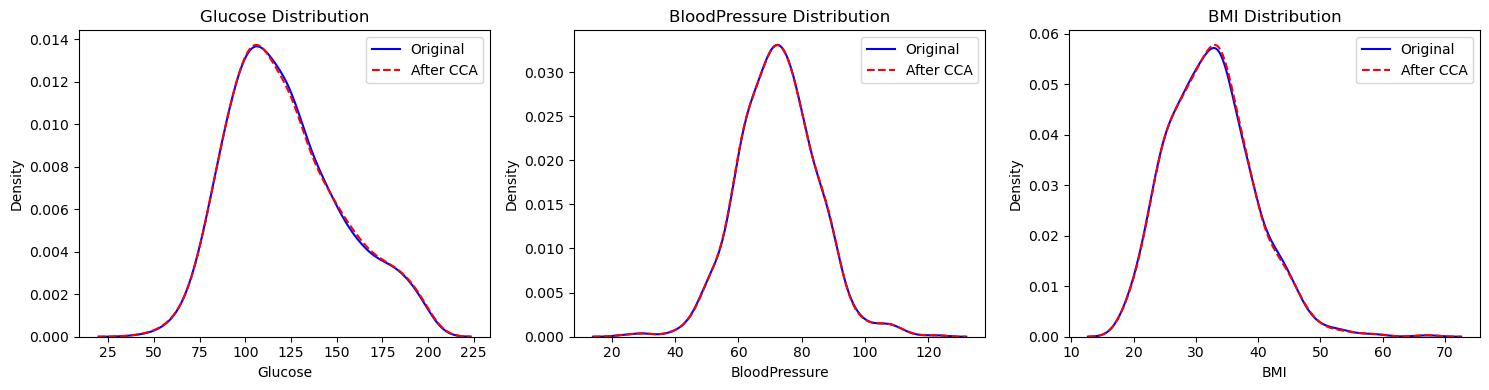

In [81]:
cols = ['Glucose', 'BloodPressure', 'BMI']
fig, axes = plt.subplots(1,3, figsize=(15, 4))

for i, col in enumerate(cols):
    sns.kdeplot(df[col], label='Original', ax=axes[i], color='blue')
    sns.kdeplot(new_df[col], label='After CCA', ax=axes[i], color='red', linestyle='--')
    axes[i].set_title(f'{col} Distribution')
    axes[i].legend()

plt.tight_layout()
plt.show()

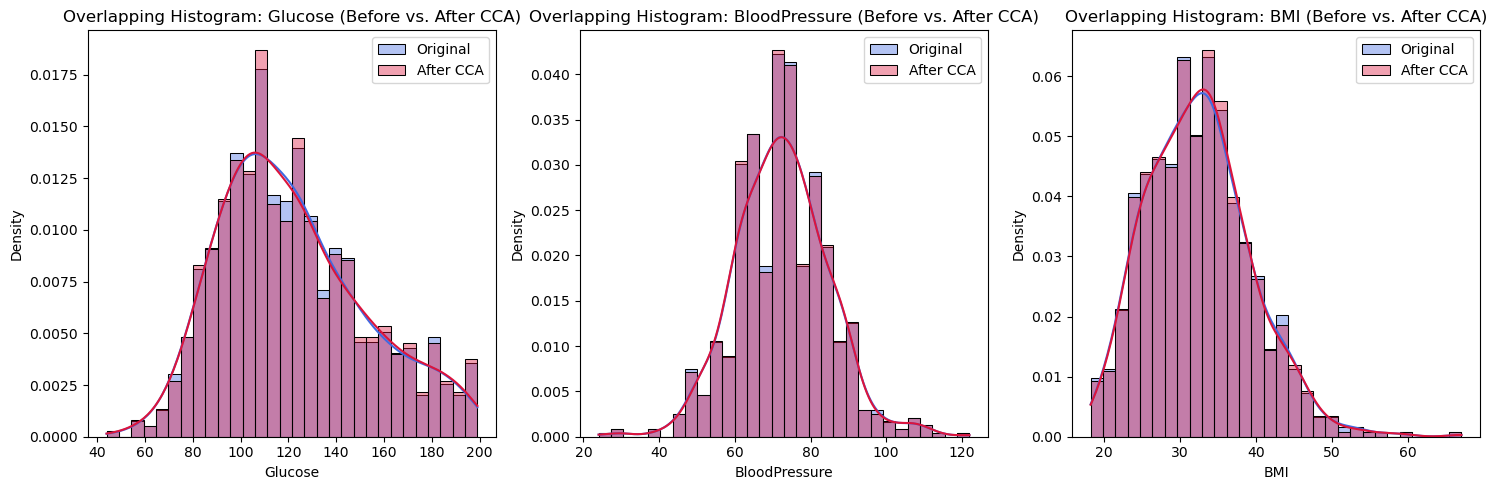

In [82]:
fig,axes=plt.subplots(1,3,figsize=(15,5))
for i,col in enumerate(cols):
    sns.histplot(
    df[col], 
    stat='density',      # Normalizes for different row counts
    bins=30, 
    color='royalblue',
    ax=axes[i],
    label='Original', 
    alpha=0.4,           # Transparency (0.0 to 1.0)
    kde=True
    )

    # Plot Dataset 2
    sns.histplot(
    new_df[col], 
    stat='density', 
    bins=30, 
    ax=axes[i],
    color='crimson', 
    label='After CCA', 
    alpha=0.4, 
    kde=True
    )

    axes[i].set_title(f'Overlapping Histogram: {col} (Before vs. After CCA)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()
plt.tight_layout()
plt.show()

In [91]:
new_df['Pregnancies']=new_df['Pregnancies'].fillna(0)

In [92]:
new_df.isna().mean()*100

Pregnancies                  0.000000
Glucose                      0.000000
BloodPressure                0.000000
SkinThickness               26.519337
Insulin                     45.856354
BMI                          0.000000
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                      0.000000
dtype: float64